# Segmentation Client (K-means / PCA) & Profilage des segments


**Méthodologie suivie :**
1. Chargement des données brutes (3 tables séparées, comme dans le vrai projet)
2. Feature engineering (RFM : Récence, Fréquence, Montant)
3. Prétraitement (standardisation)
4. Réduction de dimension (PCA)
5. Choix du nombre optimal de clusters (coude + silhouette)
6. Application du K-means
7. Validation et interprétation
8. Profilage métier (personas) — M4
9. Export des résultats pour l'équipe


## 1. Imports et configuration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)


## 2. Chargement des 3 tables brutes

⚠️ Remplace ces 3 chemins par les vrais fichiers dès que M2 les livre — le reste du notebook
n'a normalement pas besoin de changer, tant que les noms de colonnes restent identiques.

In [3]:
customers = pd.read_csv("../data/raw/simulated_customers_data.csv")
products = pd.read_csv("../data/raw/simulated_products_data.csv")
sales = pd.read_csv("../data/raw/simulated_sales_data.csv")

print("customers:", customers.shape)
print("products:", products.shape)
print("sales:", sales.shape)
customers.head()


customers: (400, 8)
products: (18, 5)
sales: (4372, 7)


,Customer_ID,Name,Age,Gender,Location,Join_Date,Total_Spent,_segment_reel_pour_validation
0,2001,Ivy A.,50,Female,Philadelphia,2022-05-17,190.02,Occasional
1,2002,Quinn B.,47,Female,Chicago,2023-08-02,1849.79,Loyal Saver
2,2003,Sam C.,25,Female,San Diego,2023-04-06,1926.19,Young Active
3,2004,Quinn D.,24,Female,San Diego,2023-06-27,1259.16,Young Active
4,2005,Diana E.,56,Female,Houston,2023-08-09,413.48,Occasional


In [4]:
sales.head()


,Sale_ID,Product_ID,Customer_ID,Date,Quantity,Sale_Price,Channel
0,1,104,2001,2023-06-10,3,63.34,Online
1,2,104,2002,2024-01-12,3,59.03,In-Store
2,3,117,2002,2024-04-19,1,133.38,Online
3,4,101,2002,2023-09-11,3,26.88,Online
4,5,111,2002,2023-08-15,1,51.57,Online


## 3. Nettoyage et jointure temporaire (mini-M2)

Cette étape reproduit en version simplifiée ce que la Data Engineer livrera en M2 (nettoyage +
jointures). Elle te permet d'avancer sans bloquer, mais **devra être remplacée par le vrai
dataset nettoyé** une fois disponible — les règles de nettoyage définitives (gestion des valeurs
aberrantes, doublons complexes, etc.) sont de sa responsabilité, pas de la tienne.

In [5]:
# Audit rapide (réflexe systématique avant toute jointure)
print("Valeurs manquantes - customers:\n", customers.isnull().sum())
print("\nDoublons - sales:", sales.duplicated().sum())


Valeurs manquantes - customers:
 Customer_ID                      0
Name                             0
Age                              0
Gender                           0
Location                         0
Join_Date                        0
Total_Spent                      6
_segment_reel_pour_validation    0
dtype: int64

Doublons - sales: 1


In [6]:
# Nettoyage minimal
customers = customers.drop_duplicates(subset="Customer_ID")
sales = sales.drop_duplicates()
customers["Total_Spent"] = customers["Total_Spent"].fillna(customers["Total_Spent"].median())

# Construction des variables RFM à partir de sales_data (agrégation par client)
sales["Date"] = pd.to_datetime(sales["Date"])
reference_date = sales["Date"].max() + pd.Timedelta(days=1)

sales["line_total"] = sales["Quantity"] * sales["Sale_Price"]

rfm = sales.groupby("Customer_ID").agg(
    recency_days=("Date", lambda x: (reference_date - x.max()).days),
    purchase_frequency=("Sale_ID", "count"),
    monetary_total=("line_total", "sum"),
).reset_index()

rfm["avg_basket_value"] = (rfm["monetary_total"] / rfm["purchase_frequency"]).round(2)

# Jointure avec les données démographiques clients
df = customers.merge(rfm, on="Customer_ID", how="inner")
print("Dataset joint :", df.shape)
df.head()


Dataset joint : (400, 12)


,Customer_ID,Name,Age,Gender,Location,Join_Date,Total_Spent,_segment_reel_pour_validation,recency_days,purchase_frequency,monetary_total,avg_basket_value
0,2001,Ivy A.,50,Female,Philadelphia,2022-05-17,190.02,Occasional,354,1,190.02,190.02
1,2002,Quinn B.,47,Female,Chicago,2023-08-02,1849.79,Loyal Saver,40,10,1849.79,184.98
2,2003,Sam C.,25,Female,San Diego,2023-04-06,1926.19,Young Active,30,12,1926.19,160.52
3,2004,Quinn D.,24,Female,San Diego,2023-06-27,1259.16,Young Active,39,8,1259.16,157.40
4,2005,Diana E.,56,Female,Houston,2023-08-09,413.48,Occasional,164,3,413.48,137.83


## 4. Analyse exploratoire (EDA)

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(df["Age"], bins=20, ax=axes[0,0], color="#2E5C9A").set_title("Distribution de l'âge")
sns.histplot(df["monetary_total"], bins=20, ax=axes[0,1], color="#2E5C9A").set_title("Montant total dépensé")
sns.histplot(df["purchase_frequency"], bins=20, ax=axes[1,0], color="#2E5C9A").set_title("Fréquence d'achat")
sns.histplot(df["recency_days"], bins=20, ax=axes[1,1], color="#2E5C9A").set_title("Récence (jours)")
plt.tight_layout()
plt.show()


<Figure size 1200x800 with 4 Axes>

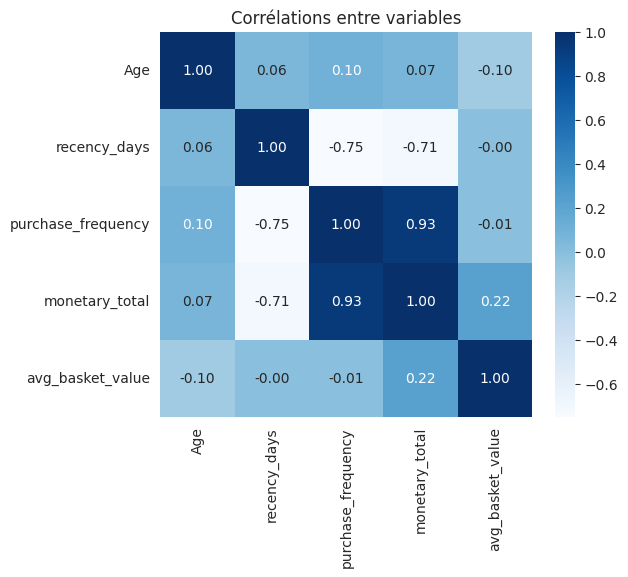

In [8]:
num_cols = ["Age", "recency_days", "purchase_frequency", "monetary_total", "avg_basket_value"]
plt.figure(figsize=(6, 5))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Corrélations entre variables")
plt.show()


## 5. Feature engineering — variables RFM

On utilise l'approche **RFM** (Récence, Fréquence, Montant), un standard en segmentation client
retail/marketing, complétée par l'âge (variable démographique).

- **Récence** : `recency_days`
- **Fréquence** : `purchase_frequency`
- **Montant** : `monetary_total`
- **+ Âge** : `Age`


In [9]:
features = ["Age", "recency_days", "purchase_frequency", "monetary_total"]
X = df[features].copy()
X.describe()


,Age,recency_days,purchase_frequency,monetary_total
count,400.000000,400.00000,400.000000,400.000000
mean,38.465000,92.90750,10.927500,2049.240100
std,14.825595,99.14577,7.115393,1405.162723
min,18.000000,1.00000,1.000000,26.650000
25%,25.000000,26.00000,3.000000,644.557500
50%,37.000000,49.50000,11.000000,2065.245000
75%,51.250000,132.00000,16.000000,2943.705000
max,69.000000,460.00000,29.000000,6513.270000


## 6. Prétraitement : standardisation

Indispensable avant K-means : sans standardisation, `monetary_total` (grandes valeurs) écraserait
`Age` (petites valeurs) dans le calcul des distances.

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=features)
X_scaled.describe().round(2)


,Age,recency_days,purchase_frequency,monetary_total
count,400.00,400.00,400.00,400.00
mean,-0.00,-0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00
min,-1.38,-0.93,-1.40,-1.44
25%,-0.91,-0.68,-1.12,-1.00
50%,-0.10,-0.44,0.01,0.01
75%,0.86,0.39,0.71,0.64
max,2.06,3.71,2.54,3.18


## 7. Réduction de dimension (PCA)

Sert à visualiser les clients en 2D et à vérifier la variance expliquée par les variables choisies

Variance expliquée : [0.64986368 0.25393107]
Variance totale expliquée : 0.904


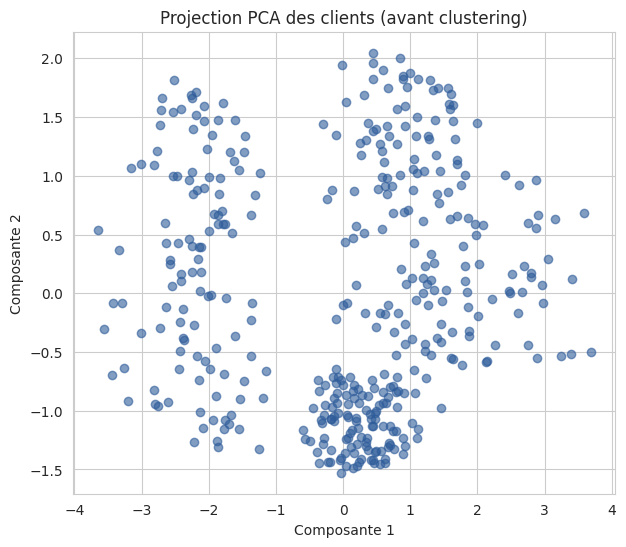

In [11]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Variance expliquée :", pca.explained_variance_ratio_)
print("Variance totale expliquée :", pca.explained_variance_ratio_.sum().round(3))

plt.figure(figsize=(7, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6, color="#2E5C9A")
plt.xlabel("Composante 1")
plt.ylabel("Composante 2")
plt.title("Projection PCA des clients (avant clustering)")
plt.show()


## 8. Choix du nombre optimal de clusters (k)

- **Méthode du coude** : où l'inertie cesse de baisser significativement
- **Score de silhouette** : qualité de séparation des clusters (proche de 1 = bon)


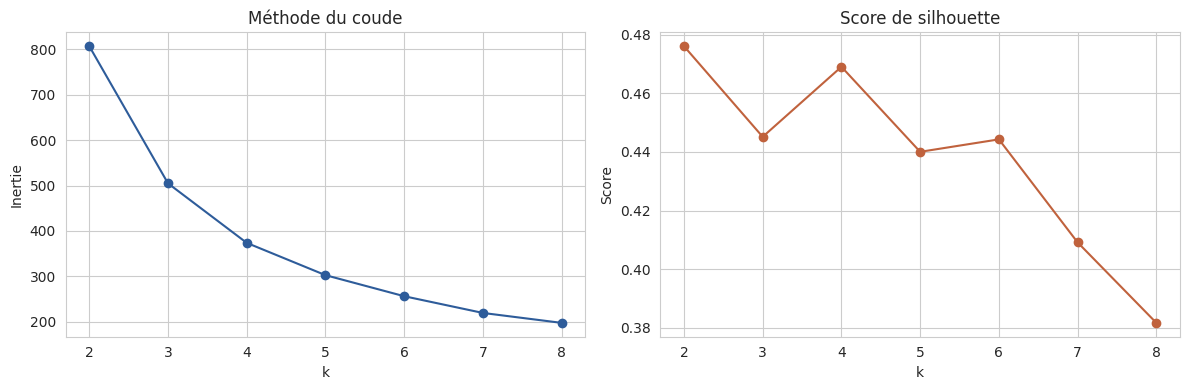

k=2 -> silhouette=0.476
k=3 -> silhouette=0.445
k=4 -> silhouette=0.469
k=5 -> silhouette=0.440
k=6 -> silhouette=0.444
k=7 -> silhouette=0.409
k=8 -> silhouette=0.382


In [15]:
inertias = []
silhouettes = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_range), inertias, marker="o", color="#2E5C9A")
axes[0].set_title("Méthode du coude")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertie")

axes[1].plot(list(k_range), silhouettes, marker="o", color="#C0623D")
axes[1].set_title("Score de silhouette")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Score")
plt.tight_layout()
plt.show()

for k, s in zip(k_range, silhouettes):
    print(f"k={k} -> silhouette={s:.3f}")


**Lecture attendue :** ce dataset simulé est construit autour de 4 profils, le score de
silhouette devrait donc être maximal (ou proche) autour de **k = 4**. Retiens le k qui offre le
meilleur compromis coude/silhouette ET qui reste interprétable d'un point de vue métier.

## 9. Application du K-means avec le k retenu

In [16]:
K_OPTIMAL = 4  # à ajuster selon ce que tu observes à l'étape précédente

kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

df["cluster"].value_counts().sort_index()


cluster
0    114
1     66
2     80
3    140
Name: count, dtype: int64

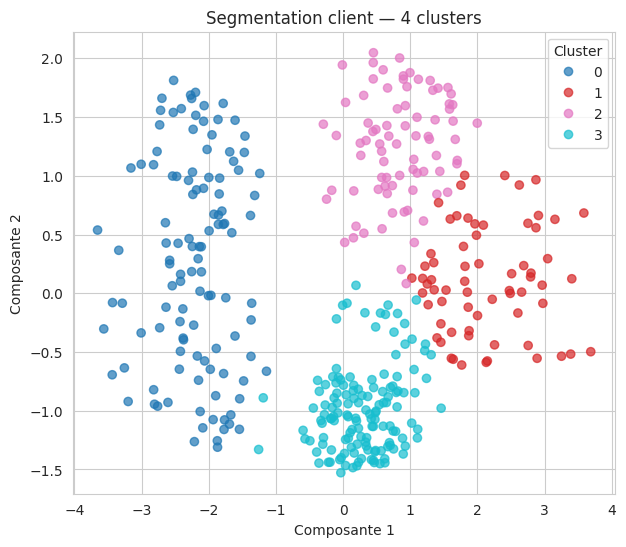

In [17]:
plt.figure(figsize=(7, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["cluster"], cmap="tab10", alpha=0.7)
plt.xlabel("Composante 1")
plt.ylabel("Composante 2")
plt.title(f"Segmentation client — {K_OPTIMAL} clusters")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.show()


## 10. Validation du clustering (spécifique à cet exercice simulé)

Cette vérification n'existera pas sur les vraies données (pas de vérité terrain), mais permet ici
de confirmer que ta méthode retrouve bien les 4 segments simulés.

In [22]:
pd.crosstab(df["cluster"], df["_segment_reel_pour_validation"])


_segment_reel_pour_validation,Loyal Saver,Occasional,VIP,Young Active
cluster,,,,
0,0,113,0,1
1,11,0,55,0
2,79,0,1,0
3,10,2,10,118


## 11. Profilage des segments

In [19]:
profile = df.groupby("cluster")[features].mean().round(1)
profile["nb_clients"] = df["cluster"].value_counts().sort_index()
profile


,Age,recency_days,purchase_frequency,monetary_total,nb_clients
cluster,,,,,
0,40.4,228.6,2.0,353.6,114
1,40.2,24.8,21.4,4131.1,66
2,57.9,44.5,14.4,2589.4,80
3,24.9,42.2,11.3,2139.9,140


In [20]:
for c in sorted(df["cluster"].unique()):
    sub = df[df["cluster"] == c]
    top_location = sub["Location"].mode()[0]
    top_gender = sub["Gender"].mode()[0]
    print(f"Cluster {c} — ville dominante: {top_location} | genre dominant: {top_gender}")


Cluster 0 — ville dominante: New York | genre dominant: Male
Cluster 1 — ville dominante: Chicago | genre dominant: Female
Cluster 2 — ville dominante: Los Angeles | genre dominant: Male
Cluster 3 — ville dominante: Los Angeles | genre dominant: Female


### Exemple de rédaction de personas (à adapter selon tes vrais résultats)

| Cluster | Persona | Description |
|---|---|---|
| 0 | **Clients VIP** | Dépenses élevées, achats fréquents, récence faible — cœur de cible à fidéliser |
| 1 | **Occasionnels** | Faible fréquence, récence élevée — cible de réactivation |
| 2 | **Jeunes actifs** | Jeunes, achats fréquents, paniers moyens — cible marketing digital/mobile |
| 3 | **Fidèles économes** | Plus âgés, fréquence correcte, panier modéré — cible fidélité |

*(à remplacer par tes vraies observations une fois le clustering exécuté sur les données réelles)*

## 12. Export des résultats pour le reste de l'équipe

Utilisé ensuite par :
- **M7** (Analyste Marketing) pour croiser les segments avec les performances de campagnes
- **M8** (Dashboard) pour afficher les segments dans Streamlit


In [21]:
output = df.drop(columns=["_segment_reel_pour_validation"])
output.to_csv("segments_clients.csv", index=False)
print("Export terminé :", output.shape)
output.head()


Export terminé : (400, 12)


,Customer_ID,Name,Age,Gender,Location,Join_Date,Total_Spent,recency_days,purchase_frequency,monetary_total,avg_basket_value,cluster
0,2001,Ivy A.,50,Female,Philadelphia,2022-05-17,190.02,354,1,190.02,190.02,0
1,2002,Quinn B.,47,Female,Chicago,2023-08-02,1849.79,40,10,1849.79,184.98,2
2,2003,Sam C.,25,Female,San Diego,2023-04-06,1926.19,30,12,1926.19,160.52,3
3,2004,Quinn D.,24,Female,San Diego,2023-06-27,1259.16,39,8,1259.16,157.40,3
4,2005,Diana E.,56,Female,Houston,2023-08-09,413.48,164,3,413.48,137.83,0


## ✅ Checklist avant de considérer M3/M4 comme terminé

- [ ] Le score de silhouette a été vérifié pour justifier le choix de k
- [ ] Chaque cluster a un persona nommé avec une description claire
- [ ] `segments_clients.csv` est exporté et poussé sur ta branche GitHub
- [ ] Dès que M2 livre le vrai dataset nettoyé/joint : relancer ce notebook en remplaçant
      les 3 fichiers chargés à l'étape 2 (et retirer l'étape 3 si M2 fournit déjà les
      variables RFM directement), puis réévaluer le k optimal sur les vraies données
